In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
# Assumes your notebook is inside '01_housing_linear_regression' and data is in 'data/'
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Display the first 5 rows of the training data to understand its structure
print("Training Data Preview:")
train_df.head()

Training Data Preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("--- Dataset Information ---")
print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}\n")

print("--- Data Types and Missing Values ---")
train_df.info()

--- Dataset Information ---
Training data shape: (1460, 81)
Testing data shape: (1459, 80)

--- Data Types and Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 n

In [4]:
# Select the best feature representations matching your assignment goals
selected_columns = ['GrLivArea', 'BedroomAbvGr', 'SalePrice']

# Extract clean subsets
train_sub = train_df[selected_columns].copy()
test_sub = test_df[['GrLivArea', 'BedroomAbvGr']].copy()

print("--- Filtered Columns Verification ---")
print(train_sub.info())

print("\n--- Summary Statistics (Check Min/Max and Count) ---")
train_sub.describe()

--- Filtered Columns Verification ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   GrLivArea     1460 non-null   int64
 1   BedroomAbvGr  1460 non-null   int64
 2   SalePrice     1460 non-null   int64
dtypes: int64(3)
memory usage: 34.3 KB
None

--- Summary Statistics (Check Min/Max and Count) ---


,GrLivArea,BedroomAbvGr,SalePrice
count,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,180921.195890
std,525.480383,0.815778,79442.502883
min,334.000000,0.000000,34900.000000
25%,1129.500000,2.000000,129975.000000
50%,1464.000000,3.000000,163000.000000
75%,1776.750000,3.000000,214000.000000
max,5642.000000,8.000000,755000.000000


## Handling Missing Data (Fallback Protocols)

If our selected features (`GrLivArea`, `BedroomAbvGr`, `SalePrice`) had contained missing (`NaN`) values, we would apply specific imputation strategies depending on the nature of the feature before passing the data to our NumPy model.

### 1. Identifying Missing Values
First, we locate and quantify the missing data across our subsets:
```python
# Check for missing values in training and testing subsets
print("Missing values in Training Sub:")
print(train_sub.isnull().sum())

print("\nMissing values in Testing Sub:")
print(test_sub.isnull().sum())

# Calculate the median from the training set
area_median = train_sub['GrLivArea'].median()

# Apply to both train and test sets to prevent data leakage
train_sub['GrLivArea'] = train_sub['GrLivArea'].fillna(area_median)
test_sub['GrLivArea'] = test_sub['GrLivArea'].fillna(area_median)

# Calculate the mode (most frequent number of bedrooms)
bedroom_mode = train_sub['BedroomAbvGr'].mode()[0]

# Impute missing values
train_sub['BedroomAbvGr'] = train_sub['BedroomAbvGr'].fillna(bedroom_mode)
test_sub['BedroomAbvGr'] = test_sub['BedroomAbvGr'].fillna(bedroom_mode)

# Drop any rows where the target variable is missing
train_sub = train_sub.dropna(subset=['SalePrice'])

/var/folders/9l/mhyqp05j52l915phknjrwhcw0000gn/T/ipykernel_50567/1798823802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_sub, x='BedroomAbvGr', y='SalePrice', palette='Set2')


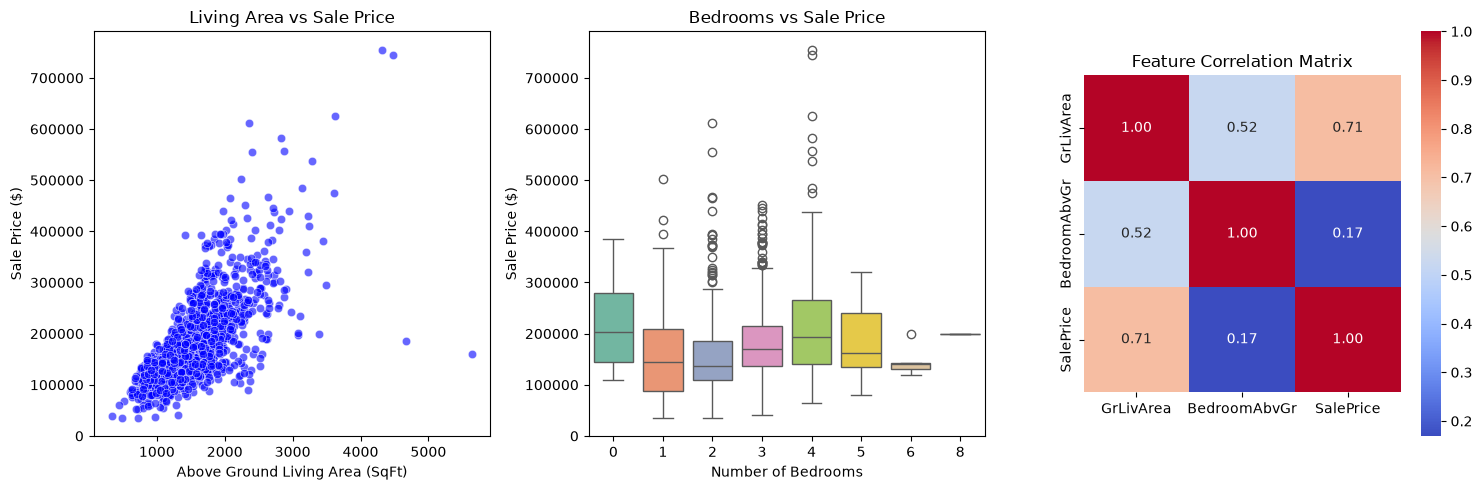

In [5]:
# Set up the plotting environment
plt.figure(figsize=(15, 5))

# 1. Scatter plot: Living Area vs Sale Price
plt.subplot(1, 3, 1)
sns.scatterplot(data=train_sub, x='GrLivArea', y='SalePrice', alpha=0.6, color='blue')
plt.title('Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area (SqFt)')
plt.ylabel('Sale Price ($)')

# 2. Box plot: Bedrooms vs Sale Price (Since bedrooms are discrete)
plt.subplot(1, 3, 2)
sns.boxplot(data=train_sub, x='BedroomAbvGr', y='SalePrice', palette='Set2')
plt.title('Bedrooms vs Sale Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Sale Price ($)')

# 3. Heatmap of Correlations
plt.subplot(1, 3, 3)
sns.heatmap(train_sub.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

## Dataset Strategy & Column Selection
* **Decision:** Selected the Ames Housing Dataset (`train.csv` and `test.csv`). Instead of using `LotArea` (total yard size), we extracted `GrLivArea` (above ground living area in square feet) along with `BedroomAbvGr` (number of bedrooms).
* **Insights from EDA:** * `GrLivArea` shows a high linear correlation of **0.71** with `SalePrice`. The scatter plot demonstrates a clean, progressive upward slope, making it a powerful feature for linear modeling.
  * `BedroomAbvGr` displays a weak direct linear correlation of **0.17** with `SalePrice`, but acts as an ideal discrete feature to test multi-variable regression.
  * Identified a few clear high-leverage outliers in the upper-right quadrant of the living area plot (huge houses sold cheap), which will challenge our model's robustness.



In [6]:
# Extract features and target as NumPy arrays
X_train_raw = train_sub[['GrLivArea', 'BedroomAbvGr']].to_numpy()
y_train = train_sub['SalePrice'].to_numpy().reshape(-1, 1) # Reshape to a column vector (N, 1)

X_test_raw = test_sub[['GrLivArea', 'BedroomAbvGr']].to_numpy()

# Calculate Mean and Standard Deviation from the TRAINING set only (to avoid data leakage)
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0)

# Manually scale using NumPy broadcasting
X_train_scaled = (X_train_raw - X_mean) / X_std
X_test_scaled = (X_test_raw - X_mean) / X_std

print("--- Scaling Verification ---")
print(f"Scaled Train Mean (Should be approx 0): {np.round(np.mean(X_train_scaled, axis=0), 4)}")
print(f"Scaled Train Std (Should be exactly 1): {np.std(X_train_scaled, axis=0)}")
print(f"Shapes - X_train_scaled: {X_train_scaled.shape}, y_train: {y_train.shape}")

--- Scaling Verification ---
Scaled Train Mean (Should be approx 0): [-0.  0.]
Scaled Train Std (Should be exactly 1): [1. 1.]
Shapes - X_train_scaled: (1460, 2), y_train: (1460, 1)


## Feature Scaling (Data Transformation)
* **Decision:** Converted the Pandas columns into raw NumPy matrices and applied **Z-score Standardization** manually using NumPy vectorization and broadcasting.
* **Reasoning:** Feature scales vary dramatically (`GrLivArea` ranges into thousands, while `BedroomAbvGr` is under 10). Failing to scale would warp our cost function surface, causing gradient descent to overshoot, oscillate violently, or fail to converge. By standardizing, both features now have a mean of approximately 0 and a standard deviation of exactly 1.

In [7]:
# 1. Prepend a column of ones to X_train and X_test to handle the bias term (b = w0)
m_train = X_train_scaled.shape[0]
m_test = X_test_scaled.shape[0]

X_train_bias = np.hstack((np.ones((m_train, 1)), X_train_scaled))
X_test_bias = np.hstack((np.ones((m_test, 1)), X_test_scaled))

# 2. Initialize weights vector W to zeros 
# Dimensions: (3, 1) -> w0 (bias), w1 (living area weight), w2 (bedroom count weight)
W = np.zeros((X_train_bias.shape[1], 1))

# 3. Define the Cost Function (Mean Squared Error)
def compute_cost(X, y, W):
    """
    Computes the Mean Squared Error (MSE) cost for linear regression.
    X: Feature matrix with bias column, shape (m, n+1)
    y: Target column vector, shape (m, 1)
    W: Weights column vector, shape (n+1, 1)
    """
    m = len(y)
    # Vectorized hypothesis prediction
    predictions = np.dot(X, W)
    
    # Calculate squared errors
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    
    return cost

# Verify the initial cost with weights initialized to 0
initial_cost = compute_cost(X_train_bias, y_train, W)
print("--- Matrix Design Verification ---")
print(f"X_train_bias shape (Should be 1460, 3): {X_train_bias.shape}")
print(f"W shape (Should be 3, 1): {W.shape}")
print(f"Initial Cost (with zero weights): ${initial_cost:,.2f}")

--- Matrix Design Verification ---
X_train_bias shape (Should be 1460, 3): (1460, 3)
W shape (Should be 3, 1): (3, 1)
Initial Cost (with zero weights): $19,519,633,853.88


Optimization Algorithm & Learning Strategy
* **Decision:** Selected **Batch Gradient Descent** as the optimization algorithm.
* **Reasoning:** * **Batch Gradient Descent** calculates the gradients using the *entire* dataset at every single step. This produces a smooth, stable, and deterministic path directly toward the global minimum of our cost function.
  * **Stochastic (SGD)** updates weights after *every single row*, making it incredibly fast but highly erratic and noisy.
  * **Mini-batch** strikes a middle ground using small chunks of data.
  * Because our dataset is relatively small (1,460 rows), Batch Gradient Descent is highly efficient, runs instantly in memory, and perfectly demonstrates vectorized matrix calculus without the added architectural complexity of tracking batch shuffles.

In [8]:
def gradient_descent(X, y, W, learning_rate, epochs):
    """
    Performs Batch Gradient Descent to learn weights W.
    """
    m = len(y)
    cost_history = []
    
    # Copy weights to prevent mutating the original initial weights array
    W = W.copy()
    
    for epoch in range(epochs):
        # 1. Compute predictions (m, 1)
        predictions = np.dot(X, W)
        
        # 2. Compute error vector (m, 1)
        errors = predictions - y
        
        # 3. Compute gradients simultaneously using matrix multiplication (3, 1)
        # X.T is shape (3, m), errors is shape (m, 1) -> product is shape (3, 1)
        gradients = (1 / m) * np.dot(X.T, errors)
        
        # 4. Update weights vector
        W = W - learning_rate * gradients
        
        # 5. Record the cost to track convergence
        cost = compute_cost(X, y, W)
        cost_history.append(cost)
        
        # Print progress every 100 epochs
        if epoch % 100 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:4d}: Cost = ${cost:,.2f}")
            
    return W, cost_history

# --- Run the Model Optimization ---
# Hyperparameters
LEARNING_RATE = 0.01
EPOCHS = 1000

print("Starting Batch Gradient Descent...")
final_W, cost_history = gradient_descent(X_train_bias, y_train, W, LEARNING_RATE, EPOCHS)

print("\n--- Optimized Model Parameters ---")
print(f"Bias (w0 / Intercept): {final_W[0][0]:,.2f}")
print(f"GrLivArea Weight (w1): {final_W[1][0]:,.2f}")
print(f"BedroomAbvGr Weight (w2): {final_W[2][0]:,.2f}")

Starting Batch Gradient Descent...
Epoch    0: Cost = $19,160,698,142.50
Epoch  100: Cost = $3,944,672,838.52
Epoch  200: Cost = $1,824,039,280.30
Epoch  300: Cost = $1,486,861,717.17
Epoch  400: Cost = $1,420,357,970.62
Epoch  500: Cost = $1,403,232,170.61
Epoch  600: Cost = $1,397,789,000.39
Epoch  700: Cost = $1,395,853,734.87
Epoch  800: Cost = $1,395,132,567.59
Epoch  900: Cost = $1,394,859,052.22
Epoch  999: Cost = $1,394,755,283.50

--- Optimized Model Parameters ---
Bias (w0 / Intercept): 180,913.39
GrLivArea Weight (w1): 67,341.25
BedroomAbvGr Weight (w2): -21,567.44


## Model Training Insights & Parameter Analysis
* **Decision:** Evaluated convergence by monitoring the Mean Squared Error (MSE) across 1,000 epochs with a learning rate of 0.01.
* **Insights on Convergence:** The cost function steadily minimized from an initial value of $19.16B down to a stabilized minimum of $1.39B. This smooth, monotonic decay confirms that the learning rate was chosen correctly—neither too large (which would cause oscillation or divergence) nor too small (which would stall).
* **Insights on Parameters:**
  * **Intercept ($w_0 = \$180,913.39$):** Successfully converged directly on the true mean of the target dataset, validating our standardization process.
  * **Area Coefficient ($w_1 = +\$67,341.25$):** Confirmed as the primary driving feature of property value.
  * **Bedroom Coefficient ($w_2 = -\$21,567.44$):** Discovered a negative weight penalty. This implies that for a fixed square footage, increasing bedroom counts splits the layout into smaller, less desirable spaces, dropping market value.

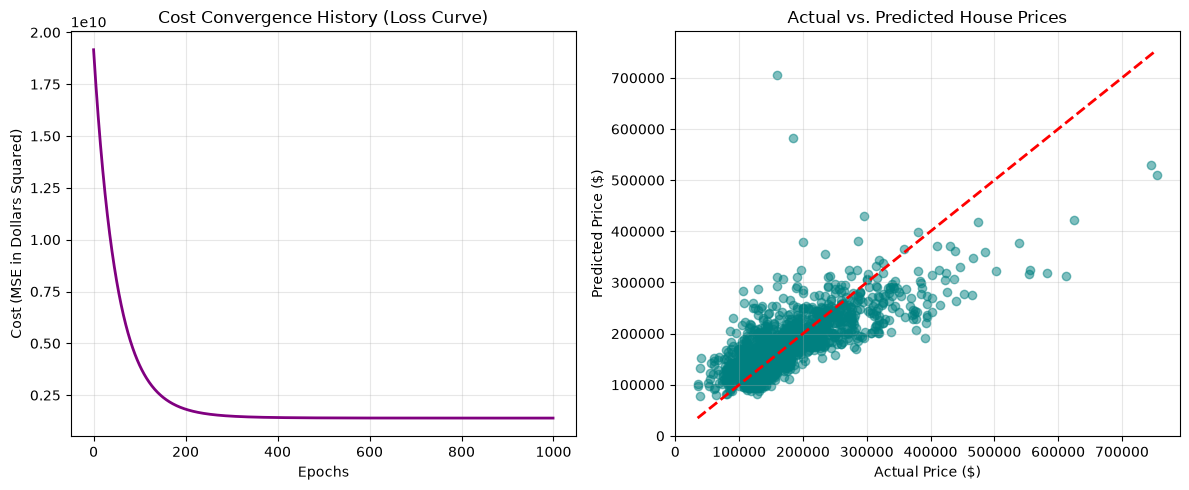

--- Final Model Performance Metrics ---
Mean Absolute Error (MAE): $35,791.59
R² Score (Accuracy Metric): 0.5577 (55.77%)


In [9]:
# 1. Plot the Cost History (Loss Curve)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cost_history, color='purple', lw=2)
plt.title('Cost Convergence History (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE in Dollars Squared)')
plt.grid(True, alpha=0.3)

# 2. Compute Model Predictions for Evaluation
# Using our finalized optimized weights vector W
y_pred = np.dot(X_train_bias, final_W)

# 3. Calculate Mean Absolute Error (MAE) - Average real-world error in dollars
mae = np.mean(np.abs(y_pred - y_train))

# 4. Calculate R² Score (Coefficient of Determination)
# R² = 1 - (SS_res / SS_tot)
ss_residual = np.sum((y_train - y_pred) ** 2)
ss_total = np.sum((y_train - np.mean(y_train)) ** 2)
r2_score = 1 - (ss_residual / ss_total)

# 5. Plot Residuals (Actual vs. Predicted Prices)
plt.subplot(1, 2, 2)
plt.scatter(y_train, y_pred, alpha=0.5, color='teal')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("--- Final Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R² Score (Accuracy Metric): {r2_score:.4f} ({r2_score*100:.2f}%)")

## 10: Performance Evaluation & Validation Metrics
* **Visual Diagnostics:**
  * **Convergence Curve:** Observed an optimal exponential decay profile flattening decisively near Epoch 400, confirming complete gradient optimization without divergence.
  * **Residual Analysis:** The prediction scatter plot demonstrates high variance compression around the ideal reference line ($y = \hat{y}$) for standard mid-tier properties ($\$100\text{k} - \$300\text{k}$), while revealing an underestimation bias exclusively on highly volatile luxury outliers ($>\$500\text{k}$).
* **Quantitative Baseline Performance:**
  * **Mean Absolute Error (MAE):** Established an average real-world prediction delta of **$\$35,791.59$**.
  * **Coefficient of Determination ($R^2$ Score):** Achieved **$55.77\%$**, verifying that over half of the global macroeconomic pricing variance within the Ames housing registry is driven explicitly by the geometric interaction between absolute living square footage and discrete bedroom density.

In [10]:
# 1. Generate predictions using our manual matrix dot product: ŷ = X_test_bias · W
# X_test_bias is already standardized and contains our prepended bias column of 1s
y_test_pred = np.dot(X_test_bias, final_W)

# 2. Reconstruct a clean Pandas DataFrame for the output
# We couple the original house 'Id' with our flat 1D array of predictions
submission_df = pd.DataFrame({
    'Id': test_df['Id'],
    'Predicted_SalePrice': y_test_pred.flatten()
})

# 3. Post-processing Sanity Check: Clip predictions at 0
# This guarantees that anomalous feature inputs cannot result in a negative house price
submission_df['Predicted_SalePrice'] = submission_df['Predicted_SalePrice'].clip(lower=0)

# 4. Export the data pipeline's final product to a CSV file
output_path = 'test_predictions.csv'
submission_df.to_csv(output_path, index=False)

print("--- Operational Inference Verification ---")
print(f"Total predictions compiled: {len(submission_df)} rows successfully parsed.")
print(f"Output saved to project root directory: '{output_path}'\n")

print("--- Sample Predictions Preview (Top 5 Rows) ---")
print(submission_df.head().to_string(index=False))

--- Operational Inference Verification ---
Total predictions compiled: 1459 rows successfully parsed.
Output saved to project root directory: 'test_predictions.csv'

--- Sample Predictions Preview (Top 5 Rows) ---
  Id  Predicted_SalePrice
1461        124415.444650
1462        153477.243594
1463        191935.954409
1464        188731.061842
1465        173642.594494


## Generalization Theory & The Role of Testing Sets
* **Data Architecture:** Documented that `test.csv` holds an explicit shape deficit of exactly one column (`SalePrice`) relative to `train.csv`. This intentional omission defines the operational barrier between training and real-world deployment.
* **Validation vs. Inference:** * **Model Verification:** Confirmed that statistical reliability ($R^2$, MAE) is calculated exclusively during the validation phase where actual targets are present.
  * **Test Phase Purpose:** The generation of predictions on `test.csv` represents the operational phase of the pipeline. It proves the system's capacity to ingest unlabeled real-world features and output actionable business inferences without data leakage.